# Machine Learning with JAX

This notebook covers building neural networks and training them with JAX. We'll start from scratch and build up to using established libraries.

**Topics covered:**
1. Neural network fundamentals in JAX
2. Parameter management with pytrees
3. Building layers and models
4. Training loops and batching
5. Using Optax for optimization
6. Using Flax/Equinox for models
7. Practical examples

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
from jax import random
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

## 1. Neural Network Basics

A neural network is just a composition of:
- Linear transformations: $y = Wx + b$
- Nonlinear activations: $y = \sigma(x)$

In JAX, we represent parameters as **pytrees** (nested dictionaries/lists).

In [2]:
# Simple linear layer

def init_linear(key, in_features, out_features):
    """Initialize a linear layer."""
    k1, k2 = random.split(key)
    # Xavier initialization
    scale = jnp.sqrt(2.0 / (in_features + out_features))
    W = random.normal(k1, (out_features, in_features)) * scale
    b = jnp.zeros(out_features)
    return {'W': W, 'b': b}

def linear(params, x):
    """Apply linear transformation."""
    return params['W'] @ x + params['b']

# Test
key = random.PRNGKey(0)
linear_params = init_linear(key, in_features=3, out_features=2)
x = jnp.array([1.0, 2.0, 3.0])

print(f"Input shape: {x.shape}")
print(f"W shape: {linear_params['W'].shape}")
print(f"Output: {linear(linear_params, x)}")

Input shape: (3,)
W shape: (2, 3)


Output: [1.36861583 0.07556286]


In [3]:
# Build a simple MLP (Multi-Layer Perceptron)

def init_mlp(key, layer_sizes):
    """
    Initialize an MLP with given layer sizes.
    layer_sizes: [input_dim, hidden1, hidden2, ..., output_dim]
    """
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    
    for i, (key, in_size, out_size) in enumerate(
        zip(keys, layer_sizes[:-1], layer_sizes[1:])
    ):
        params.append(init_linear(key, in_size, out_size))
    
    return params

def mlp(params, x, activation=jax.nn.relu):
    """Forward pass through MLP."""
    for layer_params in params[:-1]:
        x = activation(linear(layer_params, x))
    # No activation on final layer
    return linear(params[-1], x)

# Test
key = random.PRNGKey(42)
mlp_params = init_mlp(key, [3, 64, 32, 1])  # 3 inputs, 2 hidden layers, 1 output

print("MLP architecture:")
for i, p in enumerate(mlp_params):
    print(f"  Layer {i}: W shape = {p['W'].shape}")

x = jnp.array([1.0, 2.0, 3.0])
y = mlp(mlp_params, x)
print(f"\nInput: {x}")
print(f"Output: {y}")

MLP architecture:
  Layer 0: W shape = (64, 3)
  Layer 1: W shape = (32, 64)
  Layer 2: W shape = (1, 32)



Input: [1. 2. 3.]
Output: [-0.36377514]


## 2. Batched Processing with vmap

Neural networks process batches of data. In JAX, we use `vmap` to automatically vectorize over the batch dimension.

In [4]:
# Single-example forward pass
def forward_single(params, x):
    return mlp(params, x)

# Batched forward pass using vmap
# in_axes=(None, 0) means: don't batch over params, batch over axis 0 of x
forward_batch = vmap(forward_single, in_axes=(None, 0))

# Test
batch_size = 32
X_batch = random.normal(random.PRNGKey(0), (batch_size, 3))

Y_batch = forward_batch(mlp_params, X_batch)
print(f"Input batch shape: {X_batch.shape}")
print(f"Output batch shape: {Y_batch.shape}")

Input batch shape: (32, 3)
Output batch shape: (32, 1)


## 3. Loss Functions and Gradients

Training requires:
1. A loss function to minimize
2. Gradients of the loss w.r.t. parameters

In [5]:
# Mean Squared Error loss
def mse_loss(params, X, y_true):
    """Mean squared error over a batch."""
    y_pred = forward_batch(params, X)
    return jnp.mean((y_pred - y_true) ** 2)

# Cross-entropy loss for classification
def cross_entropy_loss(params, X, y_true):
    """Cross-entropy loss for multi-class classification."""
    logits = forward_batch(params, X)
    # Softmax + log for numerical stability
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    # Select the log probability of the correct class
    return -jnp.mean(jnp.sum(y_true * log_probs, axis=-1))

# Generate synthetic regression data
key = random.PRNGKey(123)
k1, k2 = random.split(key)
X_train = random.normal(k1, (100, 3))
# True function: y = x1 + 2*x2 - x3 + noise
y_train = X_train[:, 0:1] + 2*X_train[:, 1:2] - X_train[:, 2:3] + 0.1*random.normal(k2, (100, 1))

# Compute loss and gradient
loss_value = mse_loss(mlp_params, X_train, y_train)
grad_params = grad(mse_loss)(mlp_params, X_train, y_train)

print(f"Initial loss: {loss_value:.4f}")
print(f"\nGradient structure matches parameter structure:")
for i, (p, g) in enumerate(zip(mlp_params, grad_params)):
    print(f"  Layer {i}: grad W shape = {g['W'].shape}, grad b shape = {g['b'].shape}")

Initial loss: 6.4358

Gradient structure matches parameter structure:
  Layer 0: grad W shape = (64, 3), grad b shape = (64,)
  Layer 1: grad W shape = (32, 64), grad b shape = (32,)
  Layer 2: grad W shape = (1, 32), grad b shape = (1,)


## 4. Training Loop

A basic training loop:
1. Compute loss and gradients
2. Update parameters: $\theta \leftarrow \theta - \eta \nabla L$
3. Repeat

In [6]:
# Simple SGD update
def sgd_update(params, grads, learning_rate):
    """Update parameters using SGD."""
    return jax.tree.map(
        lambda p, g: p - learning_rate * g,
        params, grads
    )

# JIT compile the training step for speed
@jit
def train_step(params, X, y, learning_rate):
    """Single training step."""
    loss, grads = jax.value_and_grad(mse_loss)(params, X, y)
    params = sgd_update(params, grads, learning_rate)
    return params, loss

# Training loop
key = random.PRNGKey(42)
params = init_mlp(key, [3, 32, 16, 1])

losses = []
learning_rate = 0.01

for epoch in range(500):
    params, loss = train_step(params, X_train, y_train, learning_rate)
    losses.append(loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d}: loss = {loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

Epoch   0: loss = 6.991906
Epoch 100: loss = 0.076026
Epoch 200: loss = 0.040440
Epoch 300: loss = 0.026562
Epoch 400: loss = 0.019717

Final loss: 0.016471


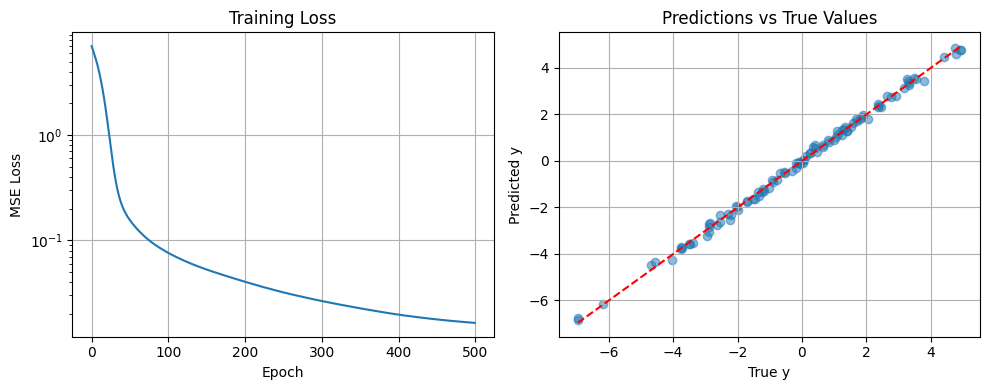

In [7]:
# Visualize training
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.semilogy(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
y_pred = forward_batch(params, X_train)
plt.scatter(y_train, y_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Adam Optimizer (Manual Implementation)

Adam is a more sophisticated optimizer that adapts learning rates per parameter.

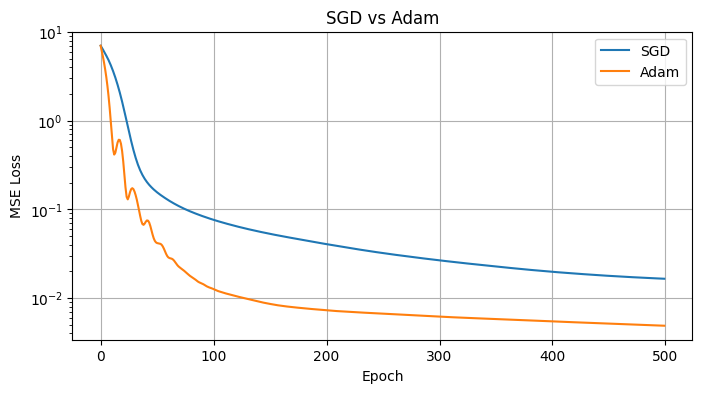

In [8]:
def init_adam_state(params):
    """Initialize Adam optimizer state (m and v for each parameter)."""
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    return {'m': m, 'v': v, 't': 0}

def adam_update(params, grads, opt_state, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    """Adam optimizer update."""
    t = opt_state['t'] + 1
    
    # Update biased first moment estimate
    m = jax.tree.map(
        lambda m_, g: beta1 * m_ + (1 - beta1) * g,
        opt_state['m'], grads
    )
    
    # Update biased second moment estimate
    v = jax.tree.map(
        lambda v_, g: beta2 * v_ + (1 - beta2) * g**2,
        opt_state['v'], grads
    )
    
    # Bias correction
    m_hat = jax.tree.map(lambda m_: m_ / (1 - beta1**t), m)
    v_hat = jax.tree.map(lambda v_: v_ / (1 - beta2**t), v)
    
    # Update parameters
    params = jax.tree.map(
        lambda p, m_, v_: p - lr * m_ / (jnp.sqrt(v_) + eps),
        params, m_hat, v_hat
    )
    
    return params, {'m': m, 'v': v, 't': t}

# Train with Adam
key = random.PRNGKey(42)
params = init_mlp(key, [3, 32, 16, 1])
opt_state = init_adam_state(params)

@jit
def train_step_adam(params, opt_state, X, y):
    loss, grads = jax.value_and_grad(mse_loss)(params, X, y)
    params, opt_state = adam_update(params, grads, opt_state, lr=0.01)
    return params, opt_state, loss

adam_losses = []
for epoch in range(500):
    params, opt_state, loss = train_step_adam(params, opt_state, X_train, y_train)
    adam_losses.append(loss)

plt.figure(figsize=(8, 4))
plt.semilogy(losses, label='SGD')
plt.semilogy(adam_losses, label='Adam')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('SGD vs Adam')
plt.legend()
plt.grid(True)
plt.show()

## 6. Using Optax for Optimization

**Optax** is JAX's official optimization library. It provides many optimizers and gradient transformations.

```python
# pip install optax
import optax

optimizer = optax.adam(learning_rate=0.001)
opt_state = optimizer.init(params)

# In training loop:
updates, opt_state = optimizer.update(grads, opt_state, params)
params = optax.apply_updates(params, updates)
```

In [9]:
# Simulating Optax-style interface
# (In practice, use the actual optax library)

class AdamOptimizer:
    """Optax-style Adam optimizer."""
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
    
    def init(self, params):
        return init_adam_state(params)
    
    def update(self, grads, opt_state, params=None):
        t = opt_state['t'] + 1
        
        m = jax.tree.map(
            lambda m_, g: self.beta1 * m_ + (1 - self.beta1) * g,
            opt_state['m'], grads
        )
        v = jax.tree.map(
            lambda v_, g: self.beta2 * v_ + (1 - self.beta2) * g**2,
            opt_state['v'], grads
        )
        
        m_hat = jax.tree.map(lambda m_: m_ / (1 - self.beta1**t), m)
        v_hat = jax.tree.map(lambda v_: v_ / (1 - self.beta2**t), v)
        
        updates = jax.tree.map(
            lambda m_, v_: -self.lr * m_ / (jnp.sqrt(v_) + self.eps),
            m_hat, v_hat
        )
        
        return updates, {'m': m, 'v': v, 't': t}

def apply_updates(params, updates):
    return jax.tree.map(lambda p, u: p + u, params, updates)

# Use the Optax-style interface
optimizer = AdamOptimizer(learning_rate=0.01)
params = init_mlp(random.PRNGKey(42), [3, 32, 16, 1])
opt_state = optimizer.init(params)

@jit
def train_step_optax_style(params, opt_state, X, y):
    loss, grads = jax.value_and_grad(mse_loss)(params, X, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = apply_updates(params, updates)
    return params, opt_state, loss

for epoch in range(100):
    params, opt_state, loss = train_step_optax_style(params, opt_state, X_train, y_train)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: loss = {loss:.6f}")

Epoch 0: loss = 6.991906
Epoch 20: loss = 0.346487
Epoch 40: loss = 0.072551
Epoch 60: loss = 0.028620
Epoch 80: loss = 0.017423


## 7. Mini-Batch Training

For large datasets, we train on mini-batches rather than the full dataset.

Epoch 0: avg loss = 6.009162


Epoch 20: avg loss = 0.011452


Epoch 40: avg loss = 0.010910


Epoch 60: avg loss = 0.005965


Epoch 80: avg loss = 0.007549


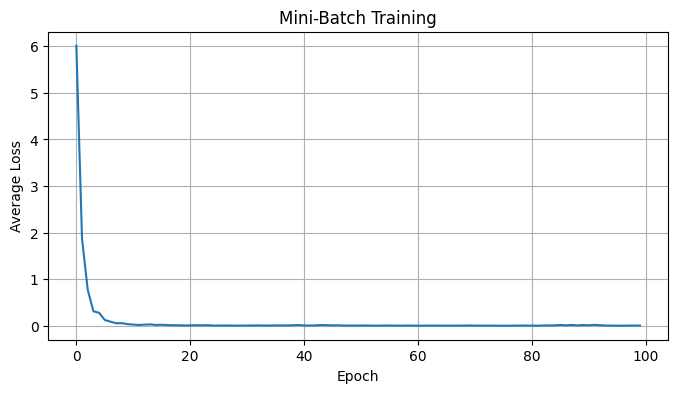

In [10]:
def get_batches(X, y, batch_size, key):
    """Generate random mini-batches."""
    n_samples = X.shape[0]
    indices = random.permutation(key, n_samples)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]
        yield X[batch_indices], y[batch_indices]

# Training with mini-batches
key = random.PRNGKey(0)
params = init_mlp(key, [3, 64, 32, 1])
opt_state = optimizer.init(params)

batch_size = 16
n_epochs = 100
minibatch_losses = []

for epoch in range(n_epochs):
    key, subkey = random.split(key)
    epoch_losses = []
    
    for X_batch, y_batch in get_batches(X_train, y_train, batch_size, subkey):
        params, opt_state, loss = train_step_optax_style(
            params, opt_state, X_batch, y_batch
        )
        epoch_losses.append(loss)
    
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    minibatch_losses.append(avg_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: avg loss = {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(minibatch_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Mini-Batch Training')
plt.grid(True)
plt.show()

## 8. Classification Example

Let's build a classifier for a more realistic task.

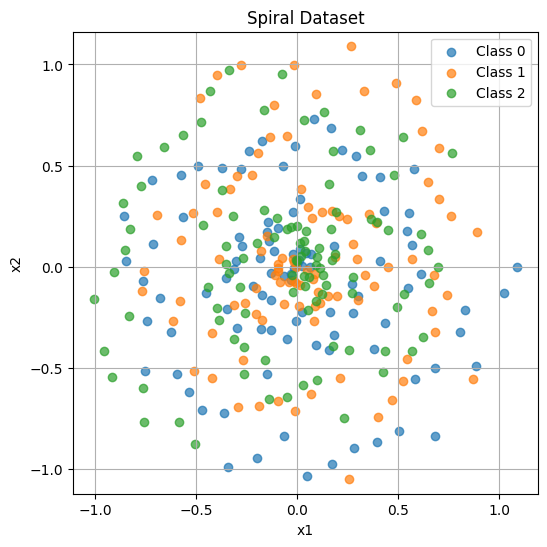

In [11]:
# Generate spiral dataset for classification
def generate_spiral_data(n_samples, n_classes, key):
    """Generate spiral dataset."""
    X = []
    y = []
    
    samples_per_class = n_samples // n_classes
    
    for c in range(n_classes):
        key, subkey = random.split(key)
        t = jnp.linspace(0, 4 * jnp.pi, samples_per_class)
        r = t / (4 * jnp.pi) + 0.1 * random.normal(subkey, (samples_per_class,))
        theta = t + c * 2 * jnp.pi / n_classes
        
        x1 = r * jnp.cos(theta)
        x2 = r * jnp.sin(theta)
        
        X.append(jnp.stack([x1, x2], axis=1))
        y.append(jnp.full(samples_per_class, c))
    
    X = jnp.concatenate(X)
    y = jnp.concatenate(y)
    
    return X, y

# Generate data
key = random.PRNGKey(42)
X_spiral, y_spiral = generate_spiral_data(300, 3, key)
y_onehot = jax.nn.one_hot(y_spiral, 3)

plt.figure(figsize=(6, 6))
for c in range(3):
    mask = y_spiral == c
    plt.scatter(X_spiral[mask, 0], X_spiral[mask, 1], label=f'Class {c}', alpha=0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Spiral Dataset')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

In [12]:
# Train classifier
def cross_entropy_loss(params, X, y_onehot):
    logits = forward_batch(params, X)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(jnp.sum(y_onehot * log_probs, axis=-1))

def accuracy(params, X, y_true):
    logits = forward_batch(params, X)
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == y_true)

# Initialize
key = random.PRNGKey(0)
params = init_mlp(key, [2, 64, 64, 3])  # 2 inputs, 3 outputs (classes)
optimizer = AdamOptimizer(learning_rate=0.01)
opt_state = optimizer.init(params)

@jit
def train_step_classification(params, opt_state, X, y):
    loss, grads = jax.value_and_grad(cross_entropy_loss)(params, X, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = apply_updates(params, updates)
    return params, opt_state, loss

# Train
losses = []
accuracies = []

for epoch in range(500):
    params, opt_state, loss = train_step_classification(
        params, opt_state, X_spiral, y_onehot
    )
    losses.append(loss)
    
    if epoch % 50 == 0:
        acc = accuracy(params, X_spiral, y_spiral)
        accuracies.append((epoch, acc))
        print(f"Epoch {epoch:3d}: loss = {loss:.4f}, accuracy = {acc:.4f}")

print(f"\nFinal accuracy: {accuracy(params, X_spiral, y_spiral):.4f}")

Epoch   0: loss = 1.0999, accuracy = 0.3700
Epoch  50: loss = 0.9336, accuracy = 0.5233
Epoch 100: loss = 0.7435, accuracy = 0.6567
Epoch 150: loss = 0.6507, accuracy = 0.6600
Epoch 200: loss = 0.5993, accuracy = 0.7033
Epoch 250: loss = 0.5591, accuracy = 0.7233
Epoch 300: loss = 0.5235, accuracy = 0.7400
Epoch 350: loss = 0.4930, accuracy = 0.7700


Epoch 400: loss = 0.4632, accuracy = 0.7767
Epoch 450: loss = 0.4374, accuracy = 0.7933

Final accuracy: 0.8000


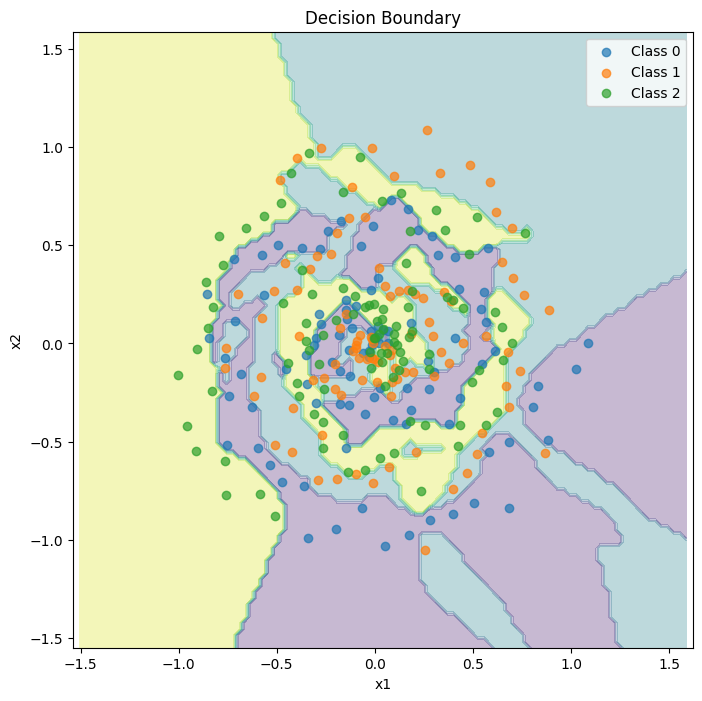

In [13]:
# Visualize decision boundary
def plot_decision_boundary(params, X, y, resolution=100):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    
    grid = jnp.c_[xx.ravel(), yy.ravel()]
    logits = forward_batch(params, grid)
    predictions = jnp.argmax(logits, axis=-1).reshape(xx.shape)
    
    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, np.array(predictions), alpha=0.3, cmap='viridis')
    for c in range(3):
        mask = y == c
        plt.scatter(X[mask, 0], X[mask, 1], label=f'Class {c}', alpha=0.7)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Decision Boundary')
    plt.legend()
    plt.axis('equal')
    plt.show()

plot_decision_boundary(params, np.array(X_spiral), np.array(y_spiral))

## 9. Regularization

Common regularization techniques in JAX:

In [14]:
# L2 Regularization (Weight Decay)
def l2_regularization(params, alpha=0.01):
    """Compute L2 penalty on weights."""
    l2_sum = sum(
        jnp.sum(p['W'] ** 2) for p in params
    )
    return alpha * l2_sum

def loss_with_l2(params, X, y, alpha=0.01):
    return cross_entropy_loss(params, X, y) + l2_regularization(params, alpha)

# Dropout (applied during forward pass)
def dropout(x, key, rate=0.5, training=True):
    """Apply dropout."""
    if not training or rate == 0:
        return x
    
    keep_rate = 1 - rate
    mask = random.bernoulli(key, keep_rate, x.shape)
    return jnp.where(mask, x / keep_rate, 0)

def mlp_with_dropout(params, x, key, rate=0.5, training=True):
    """MLP forward pass with dropout."""
    for i, layer_params in enumerate(params[:-1]):
        key, subkey = random.split(key)
        x = jax.nn.relu(linear(layer_params, x))
        x = dropout(x, subkey, rate, training)
    return linear(params[-1], x)

# Test dropout
key = random.PRNGKey(0)
x = jnp.ones(10)
print("Dropout example:")
print(f"Input: {x}")
print(f"After dropout (50%): {dropout(x, key, rate=0.5)}")
print(f"During inference: {dropout(x, key, rate=0.5, training=False)}")

Dropout example:
Input: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


After dropout (50%): [2. 2. 0. 0. 0. 2. 0. 0. 0. 2.]
During inference: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 10. Batch Normalization

Batch normalization normalizes activations and can speed up training.

In [15]:
def init_batchnorm(n_features):
    """Initialize batch normalization parameters."""
    return {
        'gamma': jnp.ones(n_features),
        'beta': jnp.zeros(n_features),
        # Running statistics (not trained)
        'running_mean': jnp.zeros(n_features),
        'running_var': jnp.ones(n_features),
    }

def batchnorm(params, x, training=True, momentum=0.1, eps=1e-5):
    """
    Batch normalization.
    x: (batch_size, features)
    """
    if training:
        mean = jnp.mean(x, axis=0)
        var = jnp.var(x, axis=0)
        
        # Update running statistics
        running_mean = (1 - momentum) * params['running_mean'] + momentum * mean
        running_var = (1 - momentum) * params['running_var'] + momentum * var
        
        new_params = {
            **params,
            'running_mean': running_mean,
            'running_var': running_var,
        }
    else:
        mean = params['running_mean']
        var = params['running_var']
        new_params = params
    
    # Normalize
    x_norm = (x - mean) / jnp.sqrt(var + eps)
    
    # Scale and shift
    y = params['gamma'] * x_norm + params['beta']
    
    return y, new_params

# Test
bn_params = init_batchnorm(4)
x = random.normal(random.PRNGKey(0), (32, 4))

y, bn_params = batchnorm(bn_params, x, training=True)
print(f"Input mean: {x.mean(axis=0)}")
print(f"Input std: {x.std(axis=0)}")
print(f"Output mean: {y.mean(axis=0)}")
print(f"Output std: {y.std(axis=0)}")

Input mean: [-0.33605332  0.00339831  0.31882572 -0.31794008]


Input std: [0.86518704 1.0126485  1.04741964 1.05655907]
Output mean: [-2.77555756e-17  0.00000000e+00  4.16333634e-17  2.77555756e-17]
Output std: [0.99999332 0.99999512 0.99999544 0.99999552]


## 11. Learning Rate Schedules

Adjusting learning rate during training can improve convergence.

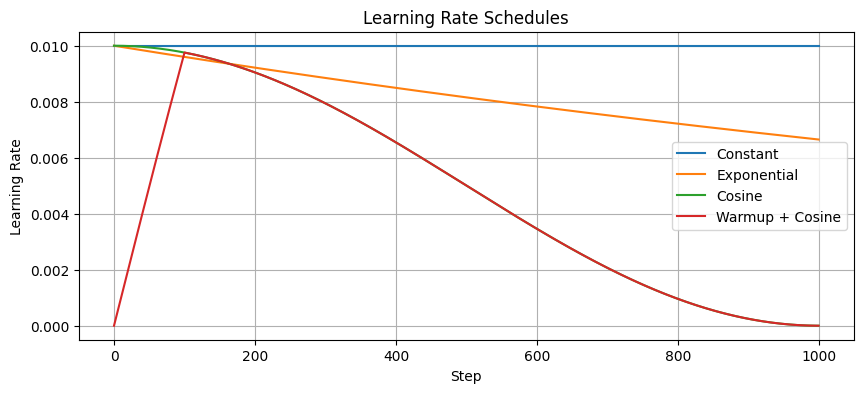

In [16]:
# Learning rate schedules

def constant_schedule(base_lr):
    """Constant learning rate."""
    return lambda step: base_lr

def exponential_decay(base_lr, decay_rate, decay_steps):
    """Exponential decay schedule."""
    return lambda step: base_lr * decay_rate ** (step / decay_steps)

def cosine_decay(base_lr, total_steps):
    """Cosine annealing schedule."""
    return lambda step: base_lr * 0.5 * (1 + jnp.cos(jnp.pi * step / total_steps))

def warmup_cosine(base_lr, warmup_steps, total_steps):
    """Warmup + cosine decay."""
    def schedule(step):
        warmup_factor = jnp.minimum(step / warmup_steps, 1.0)
        cosine_factor = 0.5 * (1 + jnp.cos(jnp.pi * step / total_steps))
        return base_lr * warmup_factor * cosine_factor
    return schedule

# Visualize schedules
steps = jnp.arange(1000)

plt.figure(figsize=(10, 4))
plt.plot(steps, vmap(constant_schedule(0.01))(steps), label='Constant')
plt.plot(steps, vmap(exponential_decay(0.01, 0.96, 100))(steps), label='Exponential')
plt.plot(steps, vmap(cosine_decay(0.01, 1000))(steps), label='Cosine')
plt.plot(steps, vmap(warmup_cosine(0.01, 100, 1000))(steps), label='Warmup + Cosine')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedules')
plt.legend()
plt.grid(True)
plt.show()

## Summary

In this notebook, we covered:

1. **Neural network basics** - Linear layers, MLPs, activation functions
2. **Parameter management** - Using pytrees for nested parameters
3. **Batching with vmap** - Automatically vectorizing over batch dimensions
4. **Loss functions** - MSE, cross-entropy
5. **Optimization** - SGD, Adam (manual and Optax-style)
6. **Training loops** - Full-batch and mini-batch
7. **Regularization** - L2, dropout
8. **Batch normalization** - Normalizing activations
9. **Learning rate schedules** - Exponential, cosine, warmup

### Key JAX patterns for ML:

- Use **pytrees** (nested dicts/lists) for parameters
- Use **vmap** for batched operations
- Use **jit** to compile training steps
- Use **value_and_grad** for efficient loss + gradient computation
- Use **jax.tree.map** for applying functions to all parameters

### Recommended libraries:

- **Optax**: Optimization (optimizers, schedules, gradient transforms)
- **Flax**: Neural network library (module system, training utilities)
- **Equinox**: Pytree-based neural networks
- **Haiku**: DeepMind's neural network library